# Project 18: Baseline RL Agent Implementation
**Evolutionary Reward Shaping for Reinforcement Learning Agents**

This notebook implements and evaluates baseline reinforcement learning (RL) agents across three environments:

| Environment | Algorithm |
|---|---|
| CartPole-v1 (Gymnasium) | DQN via Stable Baselines3 |
| LunarLander-v3 (Gymnasium) | DQN via Stable Baselines3 |
| MiniGrid-Empty-5x5-v0 | DQN via Stable Baselines3 + Tabular Q-Learning |

All episode rewards and lengths are logged to CSV files and learning curves are plotted at the end of each section.

---

## Running this notebook

**Locally (recommended):** Dependencies are managed via `requirements.txt` in the project root. If you have not yet set up the environment, follow the instructions in `README.md`. No changes to this notebook are needed.

**Google Colab:** Uncomment and run the installation cell in Section 1 before running anything else. After installation, restart the Colab runtime (Runtime > Restart runtime), then run all cells from Section 2 onwards. No other changes are needed.

---

## **1. Installation (Colab Only)**

**Local Users:** Skip this cell entirely; dependencies are already installed in your virtual environment.

**Colab Users:** Uncomment the line below, run this cell, then restart the runtime before continuing.

In [ ]:
# COLAB ONLY — uncomment the line below if running on Google Colab
# After running, go to Runtime > Restart runtime, then continue from Section 2

# %pip install stable-baselines3[extra] gymnasium[box2d] minigrid --quiet

## **2. Imports and Configuration**

In [2]:
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from minigrid.wrappers import FlatObsWrapper

print('All Imports Successful.')

All Imports Successful.


### 2.1 Path Configuration

This cell resolves the correct paths for saving logs and results regardless of whether the notebook is being run locally or on Colab.

- **Locally:** The notebook lives in `notebooks/`, so the project root is one level up. Logs and results are saved to `logs/` and `results/` at the project root.
- **Colab:** There is no project root structure, so logs and results are saved to `./logs` and `./results` relative to the notebook.

No changes needed here — this cell handles both cases automatically.

In [3]:
def _is_colab() -> bool:
  """Returns True if the notebook is running on Google Colab."""
  try:
    import google.colab
    return True
  except ImportError:
    return False


if _is_colab():
  PROJECT_ROOT = pathlib.Path('.')
  print('Environment: Google Colab')
else:
  _cwd = pathlib.Path().resolve()
  PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
  print(f'Environment: Local | Project Root: {PROJECT_ROOT}')

LOG_DIRECTORY = str(PROJECT_ROOT / 'logs')
RESULTS_DIRECTORY = str(PROJECT_ROOT / 'results')

os.makedirs(LOG_DIRECTORY, exist_ok=True)
os.makedirs(RESULTS_DIRECTORY, exist_ok=True)

print(f'Log Directory : {LOG_DIRECTORY}')
print(f'Results Directory: {RESULTS_DIRECTORY}')

Environment: Local | Project Root: D:\Projects\project18-rl-reward-shaping
Log Directory : D:\Projects\project18-rl-reward-shaping\logs
Results Directory: D:\Projects\project18-rl-reward-shaping\results


### 2.2 Global Settings

In [6]:
# Plotting style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Random seed used throughout for reproducibility
# Change this value to run with a different seed
SEED = 24

print(f'Random Seed: {SEED}')

Random Seed: 24


---
## **3. Shared Utilities**

These utilities are shared across all environments and agents. Run this section once before running any training cells.

### 3.1 Episode Reward Callback

A custom SB3 callback that records episode rewards and lengths during training. SB3's `Monitor` wrapper stores episode statistics in the `info` dictionary at the end of each episode — this callback extracts and stores them for later analysis.

In [7]:
class EpisodeLoggerCallback(BaseCallback):
  """
  Logs episode rewards and lengths at the end of every episode.
  Accessible via self.episode_rewards and self.episode_lengths after training.
  """
  def __init__(self, verbose=0):
    super().__init__(verbose)
    self.episode_rewards = []
    self.episode_lengths = []

  def _on_step(self) -> bool:
    infos = self.locals.get('infos', [])
    for info in infos:
      if 'episode' in info:
        self.episode_rewards.append(info['episode']['r'])
        self.episode_lengths.append(info['episode']['l'])
    return True

### 3.2 Logging and Plotting Utilities

In [8]:
def save_results_to_csv(episode_rewards, episode_lengths, env_name, agent_name):
  """
  Saves episode rewards and lengths to a CSV file.
  File is written to RESULTS_DIRECTORY/{env_name}_{agent_name}_results.csv
  Returns the resulting DataFrame.
  """
  df = pd.DataFrame({
    'episode': np.arange(1, len(episode_rewards) + 1),
    'reward': episode_rewards,
    'length': episode_lengths
  })
  filename = os.path.join(RESULTS_DIRECTORY, f'{env_name}_{agent_name}_results.csv')
  df.to_csv(filename, index=False)
  print(f'Results Saved To: {filename}')
  return df


def print_summary(episode_rewards, env_name, agent_name):
  """
  Prints a statistical summary of episode rewards.
  """
  rewards = np.array(episode_rewards)
  print(f'\n=== {agent_name} on {env_name} ===')
  print(f'  Episodes Completed : {len(rewards)}')
  print(f'  Mean Reward : {rewards.mean():.2f}')
  print(f'  Std Reward : {rewards.std():.2f}')
  print(f'  Min Reward : {rewards.min():.2f}')
  print(f'  Max Reward : {rewards.max():.2f}')
  print(f'  Final 10-Ep Mean : {rewards[-10:].mean():.2f}')


def plot_learning_curve(episode_rewards, env_name, agent_name, window=20, save=True):
  """
  Plots raw episode rewards and a rolling mean learning curve.
  Saves the figure to RESULTS_DIRECTORY if save=True.
  """
  episodes = np.arange(1, len(episode_rewards) + 1)
  rewards = np.array(episode_rewards)
  rolling_mean = pd.Series(rewards).rolling(window=window, min_periods=1).mean()

  fig, ax = plt.subplots()
  ax.plot(episodes, rewards, alpha=0.3, color='steelblue', label='Episode Reward')
  ax.plot(episodes, rolling_mean, color='steelblue', linewidth=2, label=f'Rolling Mean (Window={window})')
  ax.set_xlabel('Episode')
  ax.set_ylabel('Cumulative Reward')
  ax.set_title(f'{agent_name} on {env_name} - Learning Curve')
  ax.legend()
  plt.tight_layout()

  if save:
    filename = os.path.join(RESULTS_DIRECTORY, f'{env_name}_{agent_name}_learning_curve.png')
    fig.savefig(filename, dpi=150)
    print(f'Figure Saved To: {filename}')

  plt.show()


print('Utilities Loaded.')

Utilities Loaded.


---
## **4. CartPole-v1 - DQN Baseline**

CartPole-v1 tasks the agent with balancing a pole attached to a cart by applying left or right forces. The episode terminates when the pole angle exceeds 12 degrees or the cart moves more than 2.4 units from the centre. A reward of +1 is given for every timestep the pole remains upright, and the maximum possible episode reward is 500.

This is a well-understood environment that DQN typically solves within 100,000 timesteps, making it a reliable first test of the training pipeline.

In [10]:
# Training duration - increase for more thorough training
CARTPOLE_TIMESTEPS = 100_000

cartpole_log_dir = os.path.join(LOG_DIRECTORY, 'cartpole')
os.makedirs(cartpole_log_dir, exist_ok=True)
cartpole_env = Monitor(gym.make('CartPole-v1'), cartpole_log_dir)

cartpole_callback = EpisodeLoggerCallback()
cartpole_agent = DQN(
  policy='MlpPolicy',
  env=cartpole_env,
  learning_rate=1e-3,
  buffer_size=50_000,
  learning_starts=1000,
  batch_size=64,
  gamma=0.99,
  train_freq=4,
  target_update_interval=500,
  exploration_fraction=0.1,
  exploration_final_eps=0.05,
  verbose=0,
  seed=SEED
)

print(f'Training DQN on CartPole-v1 for {CARTPOLE_TIMESTEPS:,} timesteps...')
cartpole_agent.learn(
  total_timesteps=CARTPOLE_TIMESTEPS,
  callback=cartpole_callback,
  progress_bar=True
)
cartpole_env.close()
print('Training Complete.')

Output()

Training DQN on CartPole-v1 for 100,000 timesteps...


Training Complete.


Results Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_DQN_results.csv

=== DQN on CartPole-v1 ===
  Episodes Completed : 659
  Mean Reward : 151.39
  Std Reward : 112.94
  Min Reward : 9.00
  Max Reward : 500.00
  Final 10-Ep Mean : 202.70
Figure Saved To: D:\Projects\project18-rl-reward-shaping\results\CartPole-v1_DQN_learning_curve.png


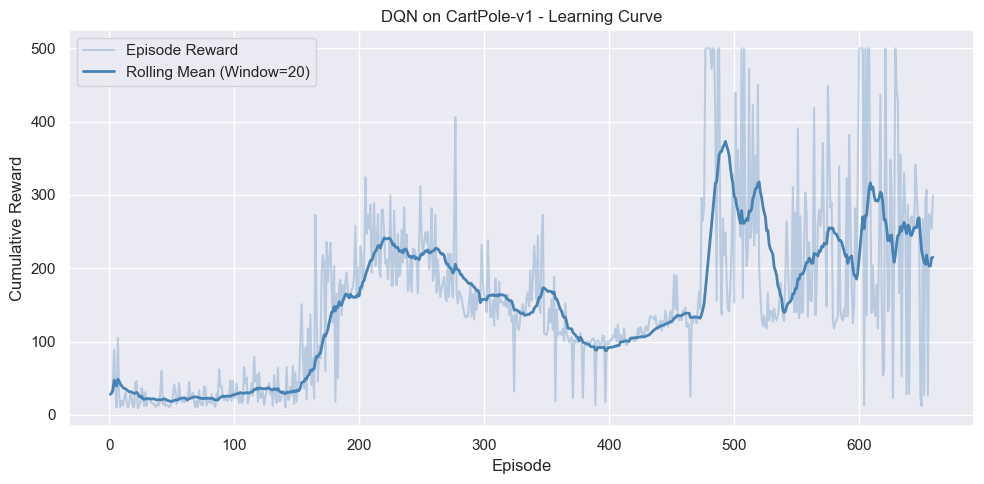

In [11]:
cartpole_df = save_results_to_csv(
  cartpole_callback.episode_rewards,
  cartpole_callback.episode_lengths,
  'CartPole-v1', 'DQN'
)
print_summary(cartpole_callback.episode_rewards, 'CartPole-v1', 'DQN')
plot_learning_curve(cartpole_callback.episode_rewards, 'CartPole-v1', 'DQN')